# UCI Bank Marketing Dataset - Exploratory Data Analysis (EDA)

## Overview & Business Context
This notebook contains a detailed Exploratory Data Analysis (EDA) of the **UCI Bank Marketing Dataset** (social/economic context enriched version). The dataset describes a direct marketing campaign conducted by a Portuguese banking institution using phone calls. The primary goal of the campaign was to encourage clients to subscribe to a term deposit.

The prediction goal is to build a machine learning model to predict the subscription outcome (variable **`y`**: `'yes'` or `'no'`).

### Notebook Objectives
1. Load and inspect the dataset's basic structure and properties.
2. Check for missing (null) values and analyze 'unknown' categories in features.
3. Provide descriptive statistical summaries for numerical and categorical features.
4. Analyze the target variable `y` distribution and document the class imbalance.
5. Contrast distributions and modes between subscribed (`y = 'yes'`) and non-subscribed (`y = 'no'`) groups.
6. Conduct statistical hypothesis tests (Welch's t-test and Chi-Square test) to establish predictive significance.
7. Visualize key relationships using matplotlib.
8. Export critical tables to CSV format for external reporting.


## 1. Setup & Data Loading
In this section, we import the necessary libraries and load the dataset. We use pandas to read the dataset from the semicolon-separated CSV file: `bank-additional/bank-additional/bank-additional-full.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats

# Set matplotlib style for clean visualizations
plt.style.use('seaborn-v0_8-whitegrid') # fallback to default if not available
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Define path to the dataset
dataset_path = 'bank-additional/bank-additional/bank-additional-full.csv'

# Load the dataset with semicolon separator
df = pd.read_csv(dataset_path, sep=';')
print('Dataset loaded successfully!')


Dataset loaded successfully!


## 2. Basic Dataset Inspection
We inspect the shape, the first and last 5 rows, the data types, and run `df.info()` to verify features and record count.


In [2]:
print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\n=== First 5 Rows ===')
display(df.head())

print('\n=== Last 5 Rows ===')
display(df.tail())

print('\n=== Column Names ===')
print(list(df.columns))

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== DataFrame Info ===')
df.info()


=== Dataset Shape ===
Rows: 41188, Columns: 21

=== First 5 Rows ===


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



=== Last 5 Rows ===


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no



=== Column Names ===
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

=== Data Types ===
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column         

## 3. Missing and Unknown Values Analysis
First, we check for standard python null/missing values. Then, we check for values labeled as `'unknown'`, which represents missing data coded inside the categorical variables.


In [3]:
# Count standard missing/null values
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100
null_summary = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage (%)': null_percentages
}).sort_values(by='Null Count', ascending=False)

print('=== Standard Null Values Summary ===')
display(null_summary)

# Check 'unknown' string value representation in every column
unknown_counts = {}
unknown_percentages = {}
for col in df.columns:
    count = (df[col] == 'unknown').sum()
    unknown_counts[col] = count
    unknown_percentages[col] = (count / len(df)) * 100

unknown_summary = pd.DataFrame({
    'Unknown Count': unknown_counts,
    'Unknown Percentage (%)': unknown_percentages
}).sort_values(by='Unknown Count', ascending=False)

print('\n=== Unknown Values Summary Table ===')
display(unknown_summary)


=== Standard Null Values Summary ===


,Null Count,Null Percentage (%)
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
month,0,0.0
day_of_week,0,0.0



=== Unknown Values Summary Table ===


,Unknown Count,Unknown Percentage (%)
default,8597,20.872584
education,1731,4.202680
housing,990,2.403613
loan,990,2.403613
job,330,0.801204
marital,80,0.194231
age,0,0.000000
contact,0,0.000000
month,0,0.000000
day_of_week,0,0.000000


## 4. Column Separation and Descriptive Summaries
Here, we separate the features into numerical and categorical columns. For numerical features, we calculate standard statistics (mean, median, mode, standard deviation, skewness). For all columns, we compute the mode summary table.


In [4]:
# Separate numerical and categorical columns (excluding target 'y')
num_cols = list(df.select_dtypes(include=[np.number]).columns)
cat_cols = list(df.select_dtypes(exclude=[np.number]).columns)
if 'y' in cat_cols:
    cat_cols.remove('y')

print(f'Numerical features ({len(num_cols)}): {num_cols}')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')

# Detailed summary table for numerical features
numeric_summary_data = []
for col in num_cols:
    desc = df[col].describe()
    median_val = df[col].median()
    
    # Handle mode calculation
    mode_series = df[col].mode()
    mode_val = mode_series.iloc[0] if not mode_series.empty else np.nan
    
    skew_val = df[col].skew()
    
    numeric_summary_data.append({
        'Feature': col,
        'count': desc['count'],
        'mean': desc['mean'],
        'median': median_val,
        'mode': mode_val,
        'std': desc['std'],
        'min': desc['min'],
        '25%': desc['25%'],
        '50%': desc['50%'],
        '75%': desc['75%'],
        'max': desc['max'],
        'skewness': skew_val
    })

numeric_summary_df = pd.DataFrame(numeric_summary_data).set_index('Feature')
print('=== Numeric Summary Table ===')
display(numeric_summary_df)

# Mode summary table for every column in the dataset
mode_summary_data = []
for col in df.columns:
    value_counts = df[col].value_counts()
    if not value_counts.empty:
        mode_val = value_counts.index[0]
        mode_cnt = value_counts.iloc[0]
        mode_pct = (mode_cnt / len(df)) * 100
    else:
        mode_val = np.nan
        mode_cnt = 0
        mode_pct = 0.0
        
    mode_summary_data.append({
        'column_name': col,
        'mode_value': mode_val,
        'mode_count': mode_cnt,
        'mode_percentage': mode_pct
    })

mode_summary_df = pd.DataFrame(mode_summary_data)
print('\n=== Mode Summary Table ===')
display(mode_summary_df)


Numerical features (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


=== Numeric Summary Table ===


,count,mean,median,mode,std,min,25%,50%,75%,max,skewness
Feature,,,,,,,,,,,
age,41188.0,40.024060,38.000,31.000,10.421250,17.000,32.000,38.000,47.000,98.000,0.784697
duration,41188.0,258.285010,180.000,85.000,259.279249,0.000,102.000,180.000,319.000,4918.000,3.263141
campaign,41188.0,2.567593,2.000,1.000,2.770014,1.000,1.000,2.000,3.000,56.000,4.762507
pdays,41188.0,962.475454,999.000,999.000,186.910907,0.000,999.000,999.000,999.000,999.000,-4.922190
previous,41188.0,0.172963,0.000,0.000,0.494901,0.000,0.000,0.000,0.000,7.000,3.832042
emp.var.rate,41188.0,0.081886,1.100,1.400,1.570960,-3.400,-1.800,1.100,1.400,1.400,-0.724096
cons.price.idx,41188.0,93.575664,93.749,93.994,0.578840,92.201,93.075,93.749,93.994,94.767,-0.230888
cons.conf.idx,41188.0,-40.502600,-41.800,-36.400,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900,0.303180
euribor3m,41188.0,3.621291,4.857,4.857,1.734447,0.634,1.344,4.857,4.961,5.045,-0.709188



=== Mode Summary Table ===


,column_name,mode_value,mode_count,mode_percentage
0,age,31,1947,4.727105
1,job,admin.,10422,25.303486
2,marital,married,24928,60.522482
3,education,university.degree,12168,29.542585
4,default,no,32588,79.120132
5,housing,yes,21576,52.384190
6,loan,no,33950,82.426920
7,contact,cellular,26144,63.474798
8,month,may,13769,33.429640
9,day_of_week,thu,8623,20.935709


## 5. Target Variable (`y`) Analysis
We analyze the distribution of the target variable `y` representing subscription to the term deposit. We plot the count of both classes using matplotlib and discuss the presence of class imbalance.


=== Target Distribution ===


,Count,Percentage (%)
y,,
no,36548,88.734583
yes,4640,11.265417


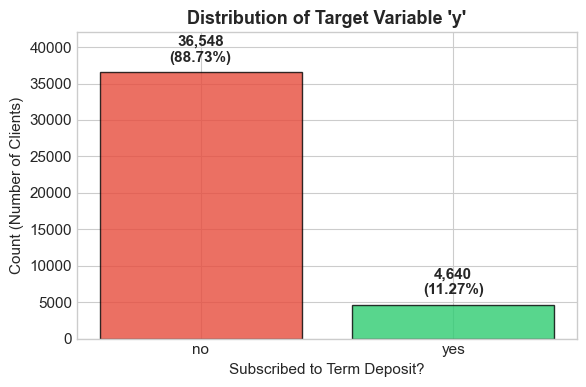

In [5]:
target_counts = df['y'].value_counts()
target_percentages = df['y'].value_counts(normalize=True) * 100

target_summary_df = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_percentages
})

print('=== Target Distribution ===')
display(target_summary_df)

# Plotting the distribution
plt.figure(figsize=(6, 4))
bars = plt.bar(target_counts.index, target_counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.8)
plt.title("Distribution of Target Variable 'y'", fontsize=13, fontweight='bold')
plt.xlabel("Subscribed to Term Deposit?", fontsize=11)
plt.ylabel("Count (Number of Clients)", fontsize=11)
plt.ylim(0, max(target_counts.values) * 1.15)

# Add labels on top of bars
for bar, pct in zip(bars, target_percentages.values):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1000,
             f'{yval:,}\n({pct:.2f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution_plot.png', dpi=100)
plt.show()


### Class Imbalance Discussion
As shown in the target distribution table and plot above, the dataset exhibits significant **class imbalance**:
- **`no`**: ~88.7% of the dataset did not subscribe to the term deposit.
- **`yes`**: ~11.3% of the dataset subscribed to the term deposit.

This has major implications for modeling: standard accuracy will be a misleading performance metric (a dummy model predicting 'no' for all instances would yield ~88.7% accuracy). When designing the model and evaluating its performance, we must focus on metrics like **Precision**, **Recall (Sensitivity)**, **F1-Score**, and **ROC-AUC**, and potentially apply sampling techniques (e.g. SMOTE) or class weights to handle the imbalance.


## 6. Grouped Comparisons by Target Class
To understand what separates subscribers from non-subscribers, we split the data into two subsets: `df_yes` and `df_no`. We compare numerical features and mode properties grouped by target status, and compile cross-tabulations for all categorical variables.


In [6]:
# Split dataframes by target
df_yes = df[df['y'] == 'yes']
df_no = df[df['y'] == 'no']
print(f'df_yes Shape: {df_yes.shape}')
print(f'df_no Shape: {df_no.shape}')

# Compare numerical columns grouped by target y
numeric_comparison = df.groupby('y')[num_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
# Flatten the multi-index column headers for clean reporting
numeric_comparison_flat = numeric_comparison.stack(level=0).reset_index()
numeric_comparison_flat.rename(columns={'level_1': 'Feature'}, inplace=True)
numeric_comparison_flat = numeric_comparison_flat[['Feature', 'y', 'count', 'mean', 'median', 'std', 'min', 'max']]

print('\n=== Numerical Columns Grouped by y ===')
display(numeric_comparison_flat)

# Compare modes grouped by target y for all columns
mode_by_target_data = []
for col in df.columns:
    if col == 'y':
        continue
    for y_val in ['yes', 'no']:
        sub_df = df[df['y'] == y_val]
        val_counts = sub_df[col].value_counts()
        if not val_counts.empty:
            mode_val = val_counts.index[0]
            mode_cnt = val_counts.iloc[0]
            mode_pct = (mode_cnt / len(sub_df)) * 100
        else:
            mode_val = np.nan
            mode_cnt = 0
            mode_pct = 0.0
        mode_by_target_data.append({
            'column_name': col,
            'target_y': y_val,
            'mode_value': mode_val,
            'mode_count': mode_cnt,
            'mode_percentage': mode_pct
        })
mode_by_target_df = pd.DataFrame(mode_by_target_data)
print('\n=== Mode Grouped by Target Table ===')
display(mode_by_target_df)

# Categorical crosstabs with raw counts and row percentages
crosstab_list = []
for col in cat_cols:
    ct_count = pd.crosstab(df[col], df['y'])
    ct_pct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    
    merged = ct_count.join(ct_pct, lsuffix='_count', rsuffix='_pct')
    merged = merged.reset_index()
    merged.insert(0, 'Feature', col)
    merged.rename(columns={col: 'Category'}, inplace=True)
    crosstab_list.append(merged)
    
    print(f'\n--- Crosstab for {col} ---')
    display(merged)

all_crosstabs_df = pd.concat(crosstab_list, ignore_index=True)


df_yes Shape: (4640, 21)
df_no Shape: (36548, 21)

=== Numerical Columns Grouped by y ===


C:\Users\DELL\AppData\Local\Temp\ipykernel_16164\523404058.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  numeric_comparison_flat = numeric_comparison.stack(level=0).reset_index()


,Feature,y,count,mean,median,std,min,max
0,age,no,36548,39.911185,38.000,9.898132,17.000,95.000
1,campaign,no,36548,2.633085,2.000,2.873438,1.000,56.000
2,cons.conf.idx,no,36548,-40.593097,-41.800,4.391155,-50.800,-26.900
3,cons.price.idx,no,36548,93.603757,93.918,0.558993,92.201,94.767
4,duration,no,36548,220.844807,163.500,207.096293,0.000,4918.000
5,emp.var.rate,no,36548,0.248875,1.100,1.482932,-3.400,1.400
6,euribor3m,no,36548,3.811491,4.857,1.638187,0.634,5.045
7,nr.employed,no,36548,5176.166600,5195.800,64.571979,4963.600,5228.100
8,pdays,no,36548,984.113878,999.000,120.656868,0.000,999.000
9,previous,no,36548,0.132374,0.000,0.409199,0.000,7.000



=== Mode Grouped by Target Table ===


,column_name,target_y,mode_value,mode_count,mode_percentage
0,age,yes,31,220,4.741379
1,age,no,31,1727,4.725293
2,job,yes,admin.,1352,29.137931
3,job,no,admin.,9070,24.816679
4,marital,yes,married,2532,54.568966
5,marital,no,married,22396,61.278319
6,education,yes,university.degree,1670,35.991379
7,education,no,university.degree,10498,28.723870
8,default,yes,no,4197,90.452586
9,default,no,no,28391,77.681405


...

y,Feature,Category,no_count,yes_count,no_pct,yes_pct
0,month,apr,2093,539,79.521277,20.478723
1,month,aug,5523,655,89.397863,10.602137
2,month,dec,93,89,51.098901,48.901099
3,month,jul,6525,649,90.953443,9.046557
4,month,jun,4759,559,89.488530,10.511470
5,month,mar,270,276,49.450549,50.549451
6,month,may,12883,886,93.565255,6.434745
7,month,nov,3685,416,89.856133,10.143867
8,month,oct,403,315,56.128134,43.871866
9,month,sep,314,256,55.087719,44.912281



--- Crosstab for day_of_week ---


y,Feature,Category,no_count,yes_count,no_pct,yes_pct
0,day_of_week,fri,6981,846,89.191261,10.808739
1,day_of_week,mon,7667,847,90.051680,9.948320
2,day_of_week,thu,7578,1045,87.881248,12.118752
3,day_of_week,tue,7137,953,88.220025,11.779975
4,day_of_week,wed,7185,949,88.332924,11.667076



--- Crosstab for poutcome ---


y,Feature,Category,no_count,yes_count,no_pct,yes_pct
0,poutcome,failure,3647,605,85.771402,14.228598
1,poutcome,nonexistent,32422,3141,91.167787,8.832213
2,poutcome,success,479,894,34.887109,65.112891


## 7. Data Visualizations
We generate visualization plots using Matplotlib only:
1. Histograms for all numerical columns.
2. Box plots of numerical columns grouped by target variable `y`.
3. Bar charts for important categorical features against target variable `y`.


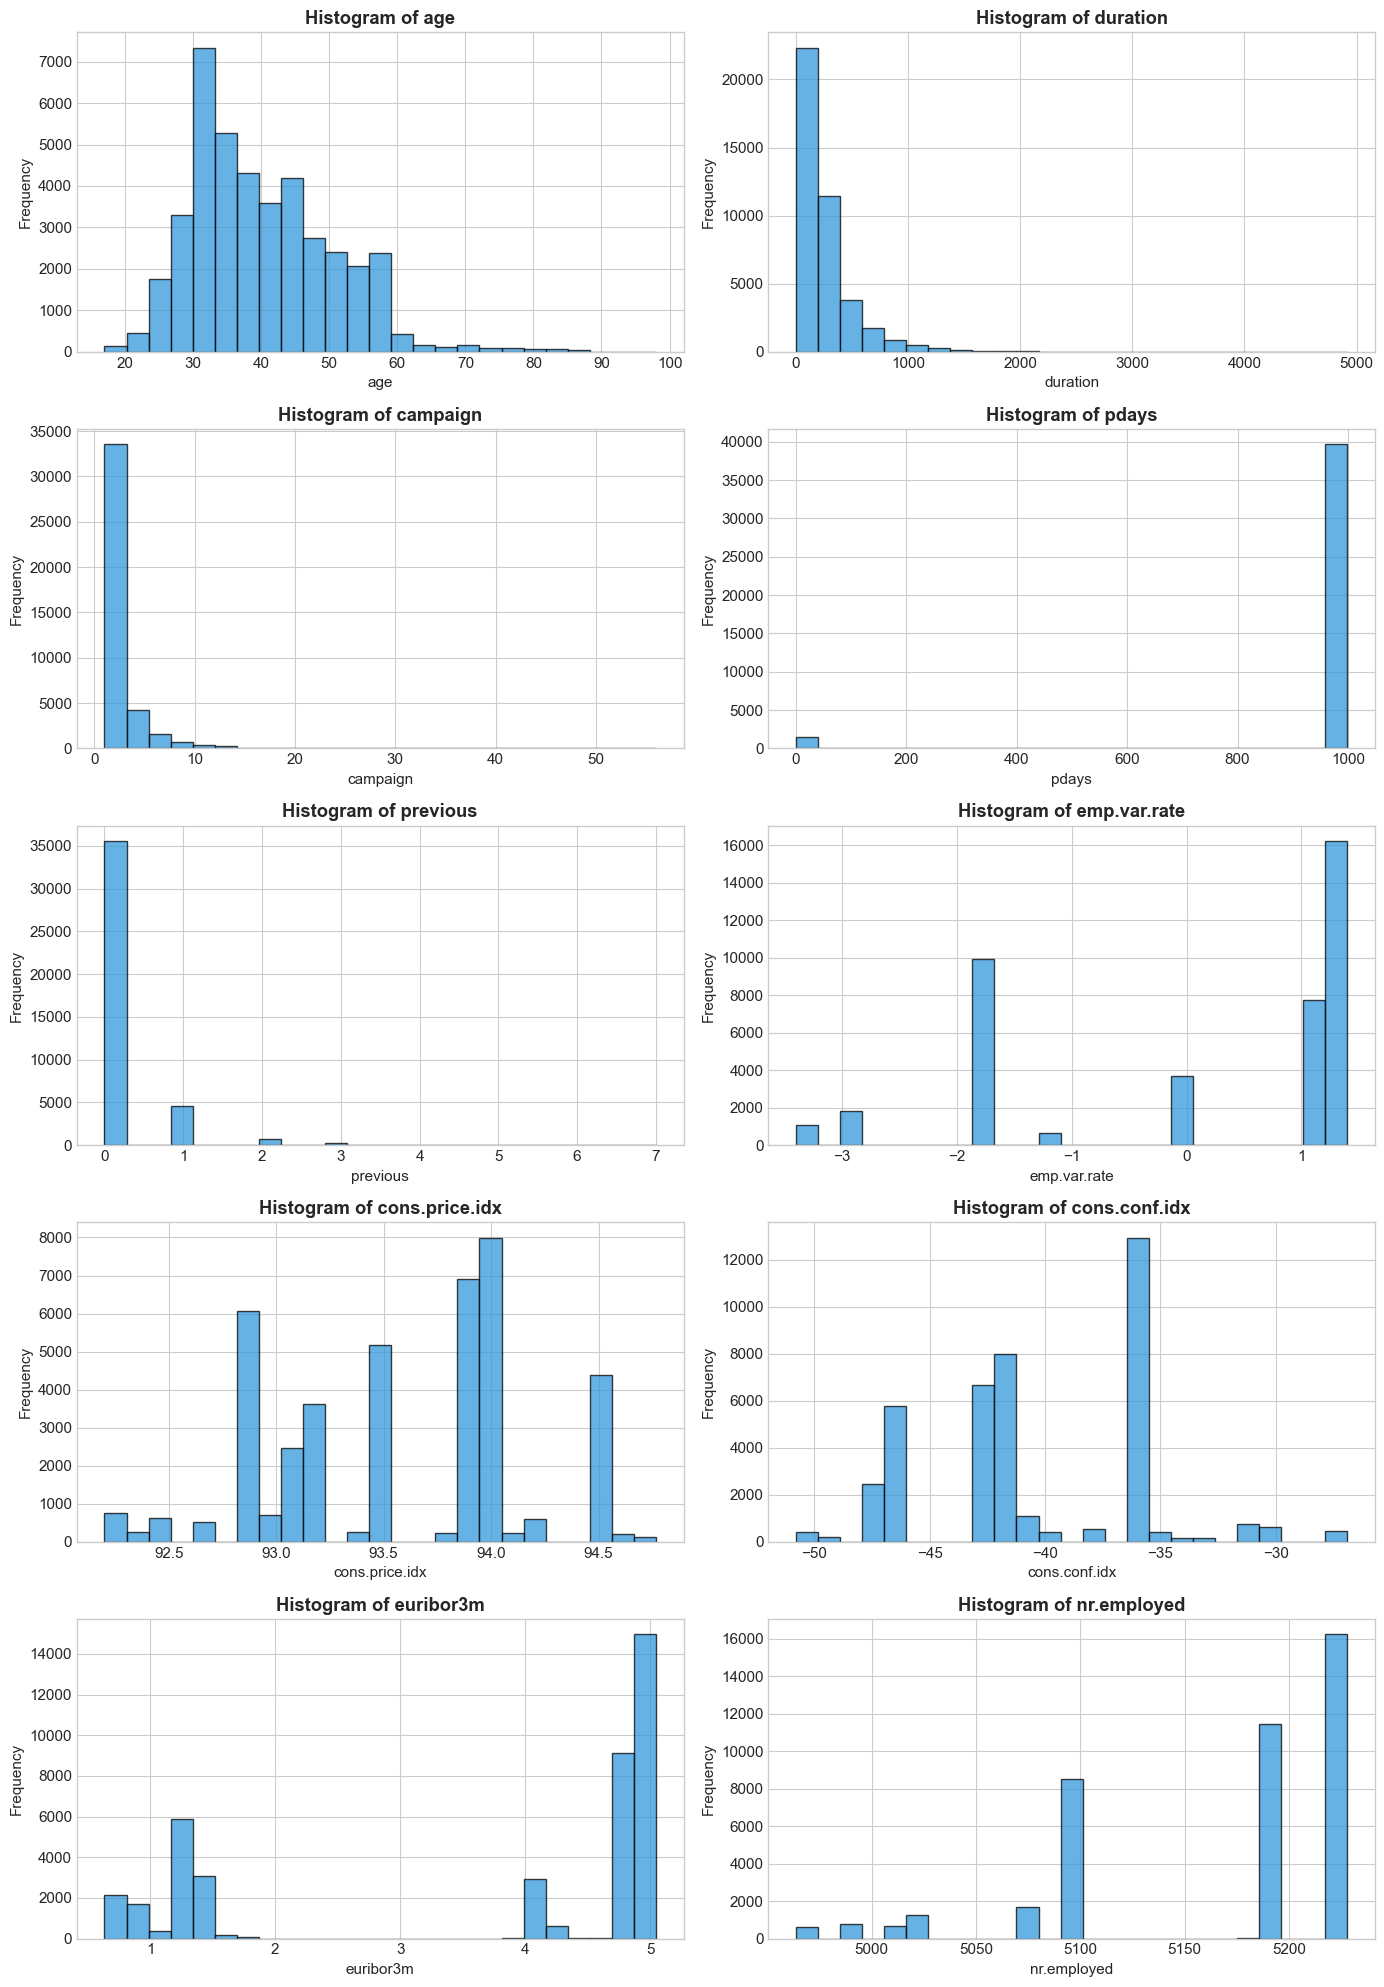

C:\Users\DELL\AppData\Local\Temp\ipykernel_16164\2617255936.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_groups, labels=['no', 'yes'], patch_artist=True,
C:\Users\DELL\AppData\Local\Temp\ipykernel_16164\2617255936.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_groups, labels=['no', 'yes'], patch_artist=True,
C:\Users\DELL\AppData\Local\Temp\ipykernel_16164\2617255936.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_groups, labels=['no', 'yes'], patch_artist=True,
C:\Users\DELL\AppData\Local\Temp\ipykernel_16164\2617255936.py:27: Matplotli

C:\Users\DELL\AppData\Local\Temp\ipykernel_16164\2617255936.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_groups, labels=['no', 'yes'], patch_artist=True,
C:\Users\DELL\AppData\Local\Temp\ipykernel_16164\2617255936.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_groups, labels=['no', 'yes'], patch_artist=True,
C:\Users\DELL\AppData\Local\Temp\ipykernel_16164\2617255936.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_groups, labels=['no', 'yes'], patch_artist=True,
C:\Users\DELL\AppData\Local\Temp\ipykernel_16164\2617255936.py:27: Matplotli

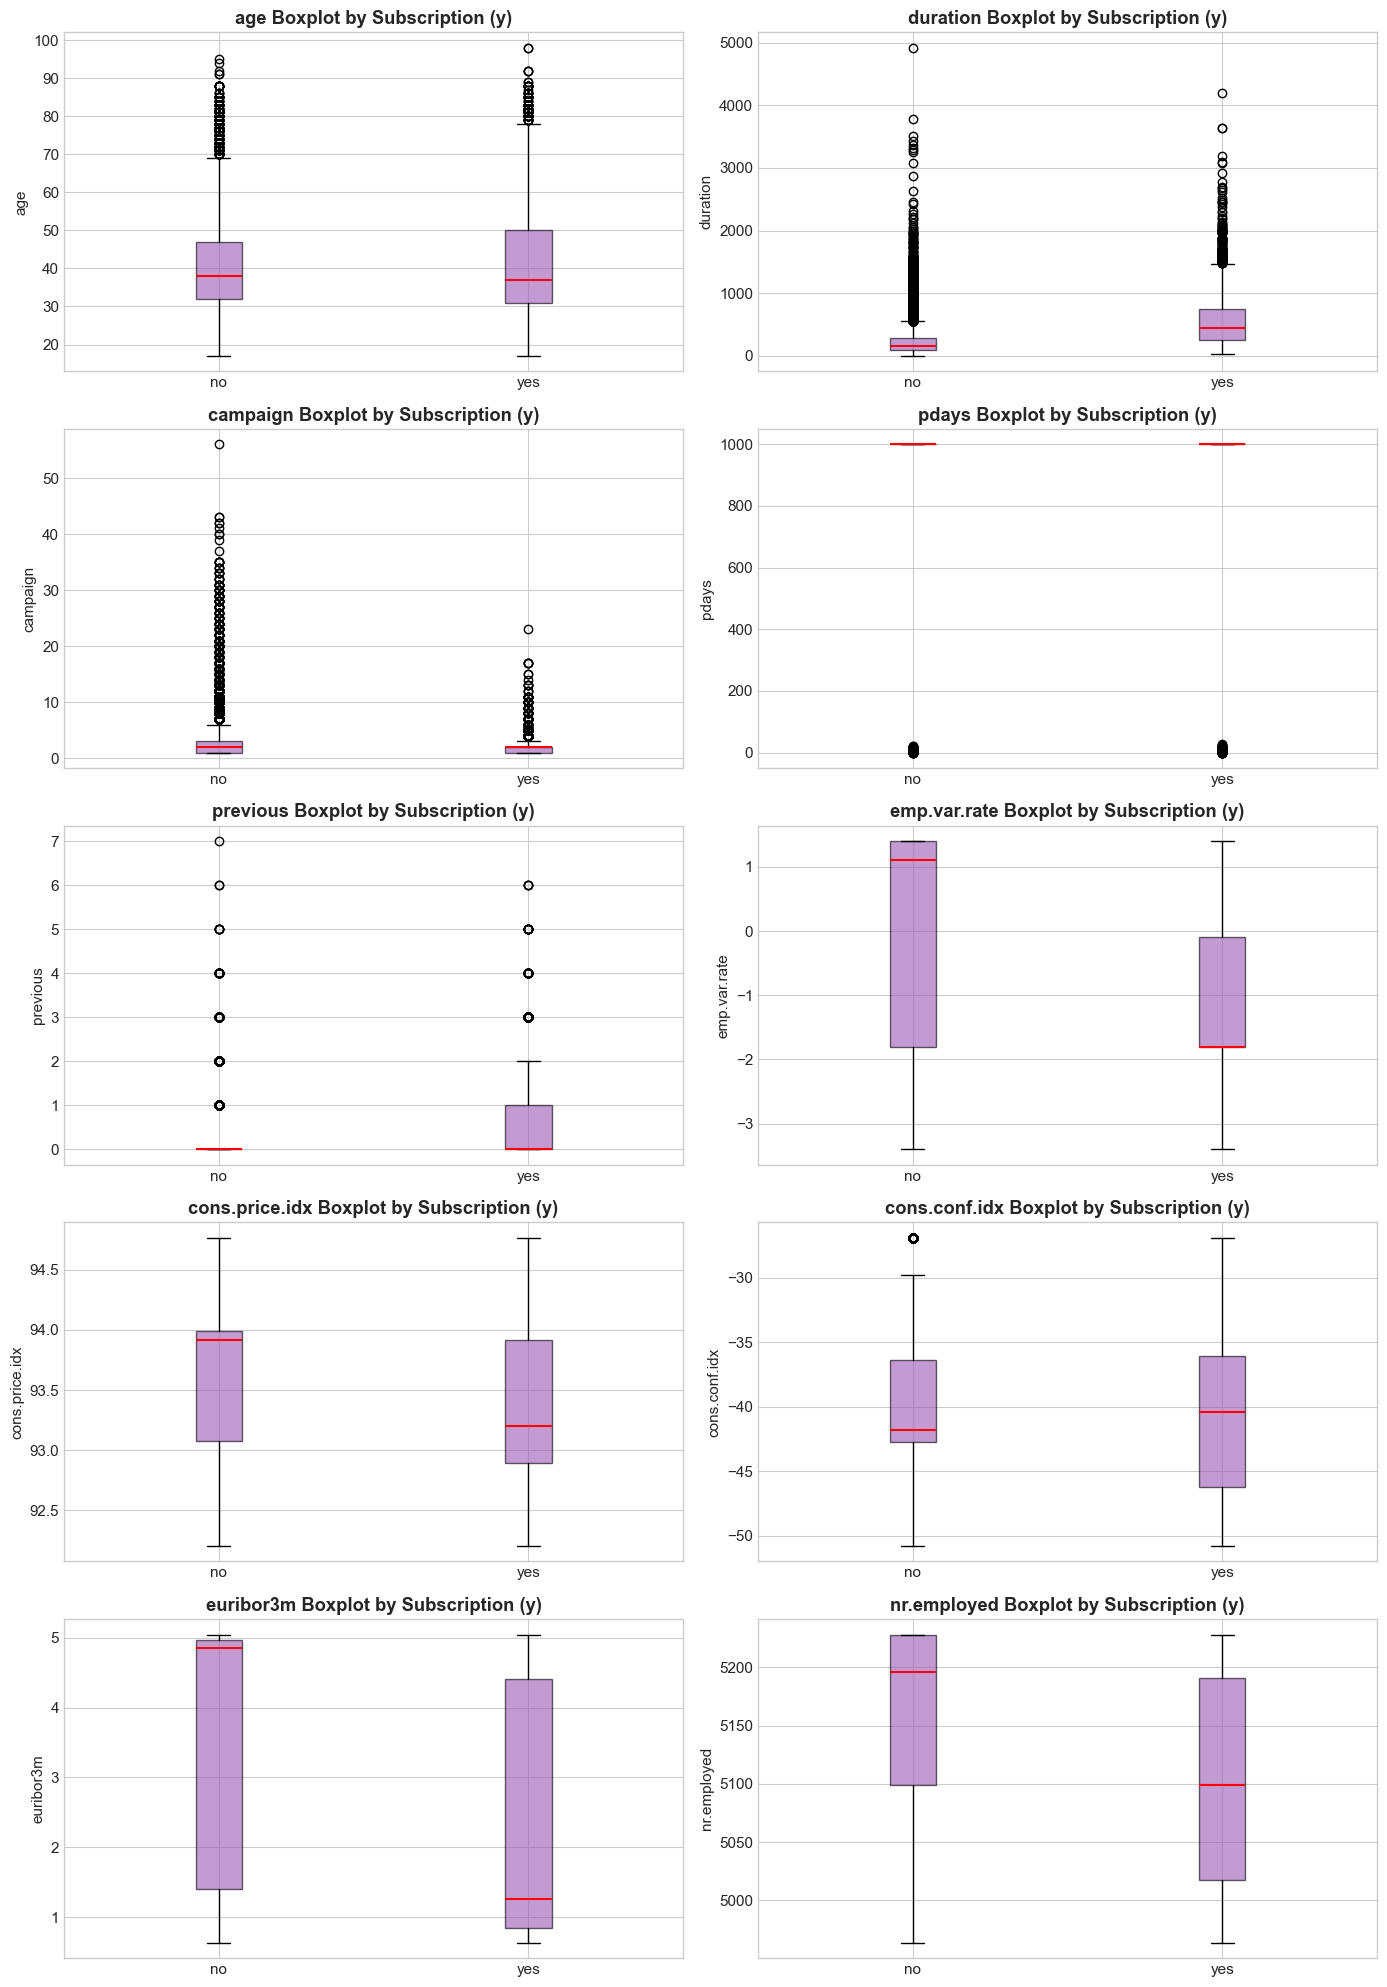

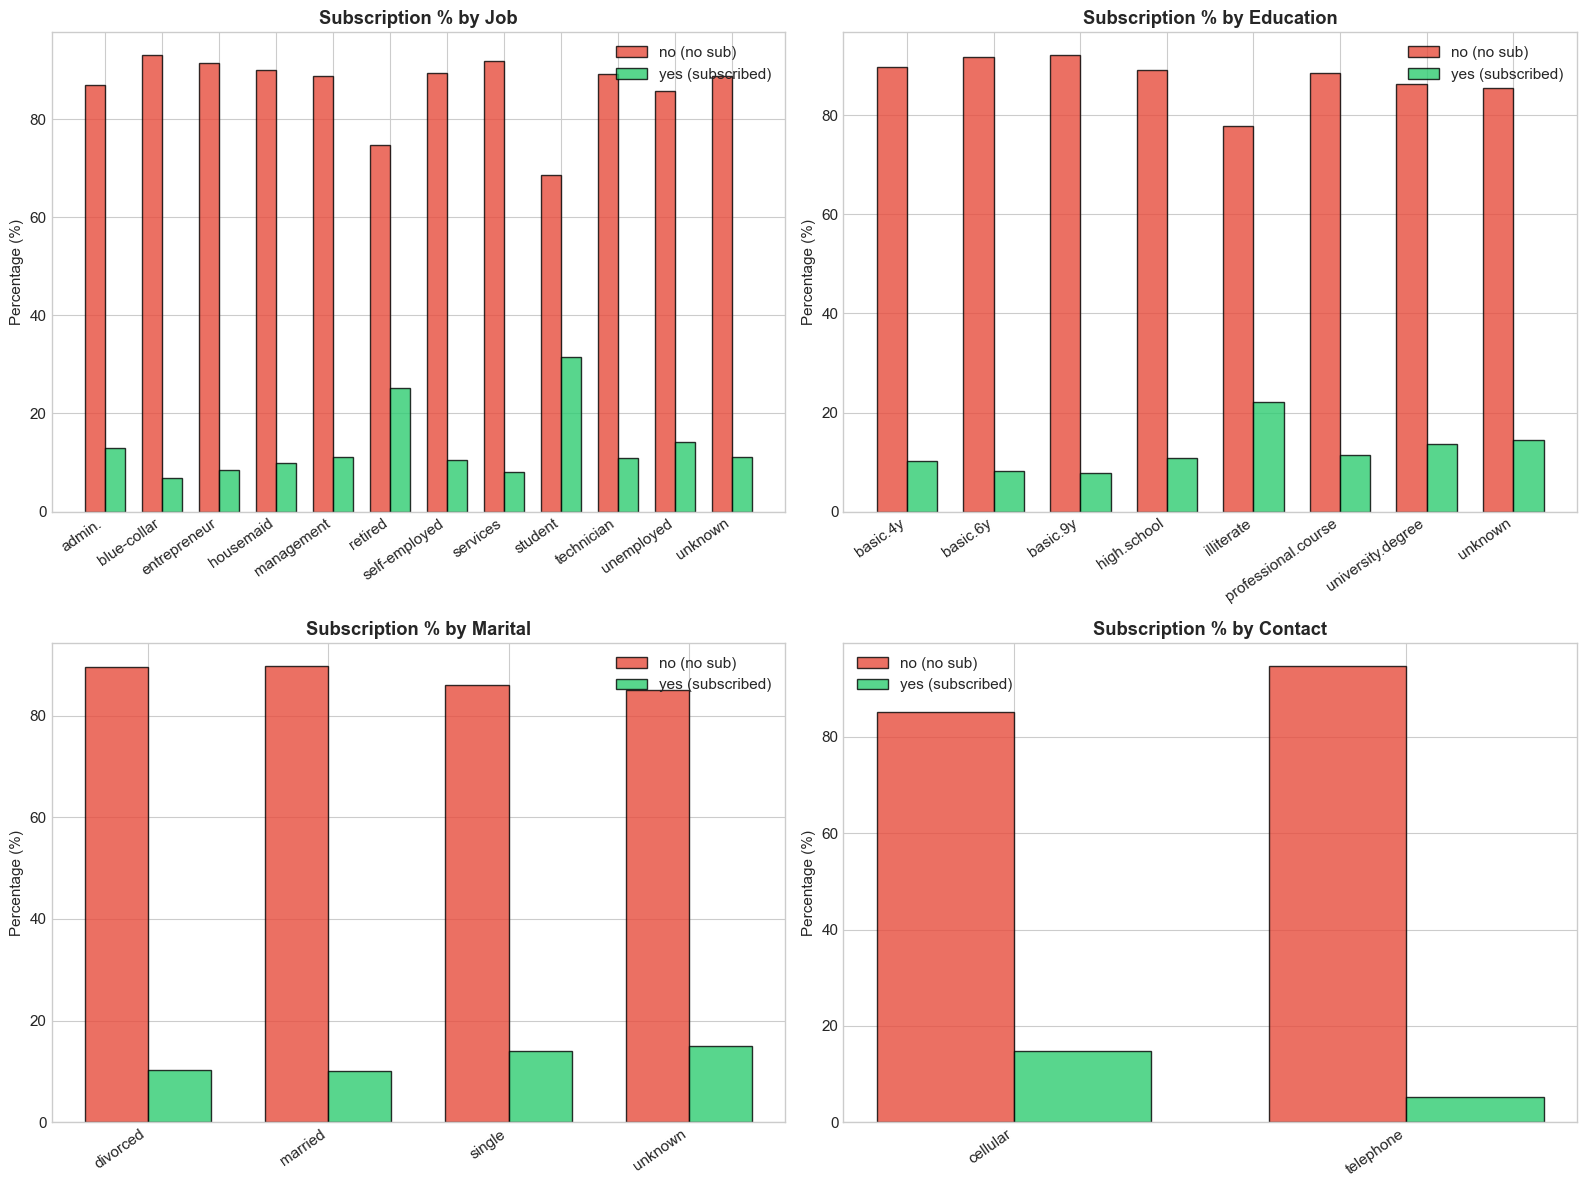

In [7]:
# 1. Histograms for numerical columns
num_features = len(num_cols)
nrows = int(np.ceil(num_features / 2))
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(14, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=25, color='#3498db', edgecolor='black', alpha=0.75)
    axes[i].set_title(f'Histogram of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('numerical_histograms.png', dpi=100)
plt.show()

# 2. Box plots of numerical columns by target variable y
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(14, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_groups = [df[df['y'] == 'no'][col].dropna(), df[df['y'] == 'yes'][col].dropna()]
    axes[i].boxplot(data_groups, labels=['no', 'yes'], patch_artist=True,
                    boxprops=dict(facecolor='#9b59b6', color='black', alpha=0.6),
                    medianprops=dict(color='red', linewidth=1.5))
    axes[i].set_title(f'{col} Boxplot by Subscription (y)', fontweight='bold')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('numerical_boxplots.png', dpi=100)
plt.show()

# 3. Bar plots of important categorical features (percentage distribution) by target status
imp_cat_cols = ['job', 'education', 'marital', 'contact']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(imp_cat_cols):
    ct_pct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    x = np.arange(len(ct_pct.index))
    width = 0.35
    
    axes[i].bar(x - width/2, ct_pct['no'], width, label='no (no sub)', color='#e74c3c', alpha=0.8, edgecolor='black')
    axes[i].bar(x + width/2, ct_pct['yes'], width, label='yes (subscribed)', color='#2ecc71', alpha=0.8, edgecolor='black')
    
    axes[i].set_title(f'Subscription % by {col.capitalize()}', fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(ct_pct.index, rotation=35, ha='right')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('categorical_crosstabs.png', dpi=100)
plt.show()


## 8. Statistical Hypothesis Testing
To identify which features show statistically significant differences across subscribers vs. non-subscribers:
- **Welch's t-test** is applied for numerical columns (comparing target subgroups without assuming equal variances).
- **Chi-Square Test of Independence** is applied for categorical columns against target variable `y`.

We define significance at a threshold of $\alpha = 0.05$ (p-value < 0.05).


In [8]:
# Welch's t-test for numerical columns
ttest_results = []
for col in num_cols:
    yes_vals = df_yes[col].dropna()
    no_vals = df_no[col].dropna()
    
    stat, p_val = stats.ttest_ind(yes_vals, no_vals, equal_var=False)
    sig = p_val < 0.05
    ttest_results.append({
        'Feature': col,
        'test_statistic': stat,
        'p_value': p_val,
        'significant': sig
    })
ttest_results_df = pd.DataFrame(ttest_results)
print('=== Welch t-test Results Table ===')
display(ttest_results_df)

# Chi-Square test of independence for categorical columns against target y
chi_results = []
for col in cat_cols:
    contingency_table = pd.crosstab(df[col], df['y'])
    stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)
    sig = p_val < 0.05
    chi_results.append({
        'Feature': col,
        'test_statistic': stat,
        'p_value': p_val,
        'significant': sig
    })
chi_results_df = pd.DataFrame(chi_results)
print('\n=== Chi-Square Test Results Table ===')
display(chi_results_df)


=== Welch t-test Results Table ===


,Feature,test_statistic,p_value,significant
0,age,4.779543,1.804793e-06,True
1,duration,55.500166,0.000000e+00,True
2,campaign,-20.249378,4.099550e-89,True
3,pdays,-32.250869,1.663432e-206,True
4,previous,28.125534,1.675951e-161,True
5,emp.var.rate,-59.136663,0.000000e+00,True
6,cons.price.idx,-24.082467,6.916521e-122,True
7,cons.conf.idx,8.636458,7.588202e-18,True
8,euribor3m,-62.579872,0.000000e+00,True
9,nr.employed,-60.975156,0.000000e+00,True



=== Chi-Square Test Results Table ===


,Feature,test_statistic,p_value,significant
0,job,961.242440,4.189763e-199,True
1,marital,122.655152,2.068015e-26,True
2,education,193.105905,3.305189e-38,True
3,default,406.577515,5.161958e-89,True
4,housing,5.684496,5.829448e-02,False
5,loan,1.094028,5.786753e-01,False
6,contact,862.318364,1.525986e-189,True
7,month,3101.149351,0.000000e+00,True
8,day_of_week,26.144939,2.958482e-05,True
9,poutcome,4230.523798,0.000000e+00,True


## 9. Data Leakage Warning (`duration` column)
During Exploratory Data Analysis, we analyze `duration` (call duration in seconds) and observe that it is a strong predictor of subscription success. Subscribed clients tend to have much longer call durations (mean of ~553 seconds vs ~220 seconds for unsubscribed clients, backed by an extremely high t-test statistic).

> [!IMPORTANT]
> **`duration` represents target leakage!**
> In a realistic production deployment of this predictive model, the model is run *before* the marketing calls are executed (to prioritize which clients to call). The length of the conversation is obviously unknown before the call starts. After the call ends and duration is known, the subscription outcome `y` is already established. Therefore, **including `duration` as an input feature creates data leakage and leads to unrealistic test performance. It must be removed before model training.**


## 10. Saving EDA Outputs
We create a directory named `eda_outputs/` and save all summary tables calculated during this EDA as CSV files for reporting and modeling tasks.


In [9]:
output_dir = 'eda_outputs'
os.makedirs(output_dir, exist_ok=True)

# Save tables to CSV
numeric_summary_df.to_csv(os.path.join(output_dir, 'numeric_summary.csv'))
mode_summary_df.to_csv(os.path.join(output_dir, 'mode_summary.csv'), index=False)
target_summary_df.to_csv(os.path.join(output_dir, 'target_distribution.csv'))
unknown_summary.to_csv(os.path.join(output_dir, 'unknown_values_summary.csv'))
numeric_comparison_flat.to_csv(os.path.join(output_dir, 'numeric_comparison_by_target.csv'), index=False)
mode_by_target_df.to_csv(os.path.join(output_dir, 'mode_by_target.csv'), index=False)
ttest_results_df.to_csv(os.path.join(output_dir, 'ttest_results.csv'), index=False)
chi_results_df.to_csv(os.path.join(output_dir, 'chi_square_results.csv'), index=False)

print('All 8 summary files saved successfully in the eda_outputs/ directory!')
print(os.listdir(output_dir))


All 8 summary files saved successfully in the eda_outputs/ directory!
['chi_square_results.csv', 'mode_by_target.csv', 'mode_summary.csv', 'numeric_comparison_by_target.csv', 'numeric_summary.csv', 'target_distribution.csv', 'ttest_results.csv', 'unknown_values_summary.csv']
